# Lab 2 Report

### Group Members:

In [ ]:
import numpy as np # Import the numpy library
import matplotlib.pyplot as plt # Import the pyplot module from matplotlib

In [ ]:
from IPython.display import Image #For displaying images in colab jupyter cell

# Exercise 1: Loops vs Numpy operations

In [ ]:
import time # Import time to measure computational efficiency of the code

In [ ]:
# Generate a 1000x1000 2D array of random numbers
arr2d_1 = np.random.randn(1000, 1000) * 10
arr2d_2 = np.random.randn(1000, 1000) * 10

In [ ]:
# Elementwise addition using loop

arr2d_3_loop = np.zeros((1000, 1000)) # Create a placeholder array for arr2d_3

start_time_loop = time.time() # start time of the code

# YOUR CODE HERE FOR ELEMENTWISE ADDITION USING TWO NESTED LOOPS
for i in range(len(arr2d_1)):  # Loop over each row of the array arr2d_1
  for j in range(len(arr2d_1[i])): # Loop over each column of the current row
    arr2d_3_loop[i][j] = arr2d_1[i][j] + arr2d_2[i][j] # Add the elements and store in array arr2d_3

end_time_loop = time.time() # end time of the code

elapsed_time_loop = end_time_loop - start_time_loop # end time - start time -> elapsed time in seconds
print(elapsed_time_loop)

1.073035478591919


In [ ]:
# Elementwise addition using Numpy function

start_time_np = time.time()

# add the two given arrays using np elementwise addition operator
arr2d_3_np = np.add(arr2d_1, arr2d_2)

end_time_np = time.time()

elapsed_time_np = end_time_np - start_time_np
print(elapsed_time_np)

0.010213136672973633


In [ ]:
# Make sure two outputs are equivalent

np.sum(arr2d_3_loop == arr2d_3_np) == 1000 * 1000 # Should output True if the outputs are same

True

### Which computation is faster and by what factor?
### e.g. a code that takes 0.1s is faster by a factor of 10 compared to a code that takes 1s


### Answer: The computation with numpy is faster than loop by a factor of 513.6440273%

# Exercise 2: Generate Triangular Waveform

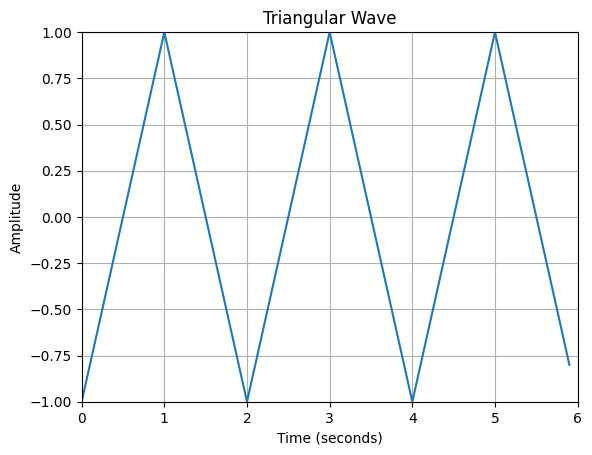

In [ ]:
# Your code here
amplitude = 1
f = 0.5
fs = 10
t_duration = 6

period = 1/f

# Generate an array of time points.
t= np.arange(0, t_duration, 1/fs)

# Define a function to itreate through to calculate the value of a triangular wave at a given time point.
def triangular_wave (tp, period, amplitude):
  phase = (tp % period) / period
  if phase <= 0.5:
    return 4* amplitude * phase - amplitude
  else:
    return -4 * amplitude * phase + 3 * amplitude

# Generate the triangular wave values for each time point.
triangle_waves = np.array([triangular_wave(tp, period, amplitude) for tp in t])

# Plot the triangular wave using matplotlib.
plt.plot(t, triangle_waves)
plt.title('Triangular Wave')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.xlim(0, 6)
plt.ylim(-1, 1)
plt.grid()
plt.show()

# Exercise 3: Sinusoidal Generator

In [59]:
# Define generate_sine function
def generate_sine(t_duration, f0, fs):

    # YOUR CODE HERE
    t_arr = np.arange(0, t_duration, 1/fs) # Generate an array of time points
    amplitude = 2 * np.pi * f0 # Calculate the amplitude using the given formula.
    amplitudes = 1 * np.sin(amplitude * t_arr) #  Calculate the sine wave values.


    # Return 1D numpy arrays each containing timepoints and sine waveform amplitudes
    return t_arr, amplitudes

In [60]:
# parameter set 1
t_duration_1 = 5
f0_1 = 0.5
fs_1 = 100
t_arr_1, amplitudes_1 = generate_sine(t_duration_1, f0_1, fs_1)

# parameter set 2
t_duration_2 = 5
f0_2 = 1.
fs_2 = 100
t_arr_2, amplitudes_2 = generate_sine(t_duration_2, f0_2, fs_2)

# parameter set 3
t_duration_3 = 5
f0_3 = 1.5
fs_3 = 100
t_arr_3, amplitudes_3 = generate_sine(t_duration_3, f0_3, fs_3)

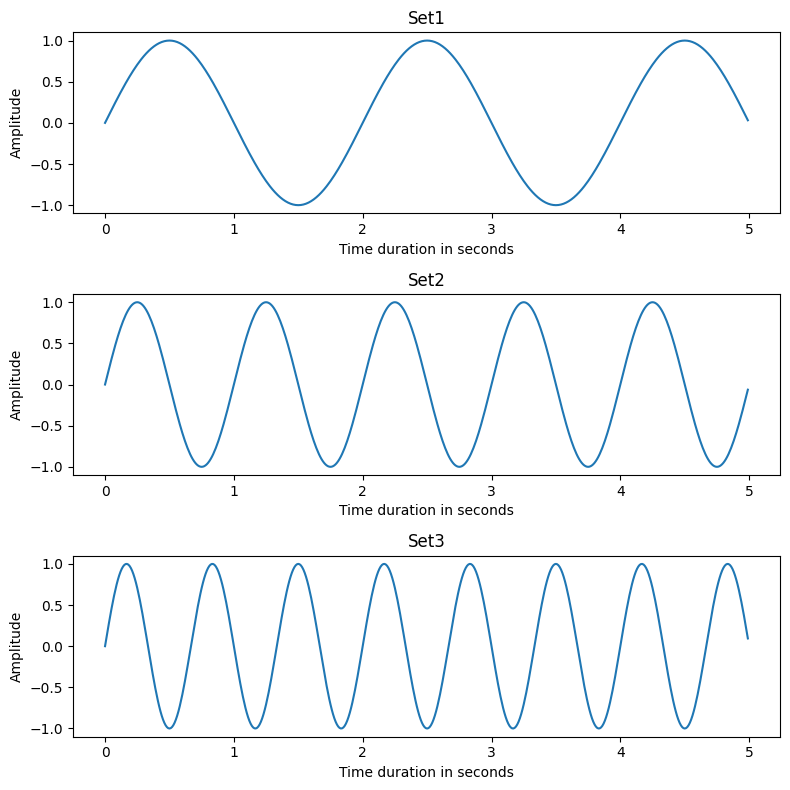

In [61]:
# Plot 3 x 1 subplot showing all three waveform

# YOUR CODE HERE
# Create a new figure
fig = plt.figure(2,figsize=(8,8))

# Create the first subplot.
plt.subplot(311)
plt.plot(t_arr_1, amplitudes_1)
plt.title('Set1')
plt.xlabel('Time duration in seconds')
plt.ylabel('Amplitude')


# Create the second subplot.
plt.subplot(312)
plt.plot(t_arr_2, amplitudes_2)
plt.title('Set2')
plt.xlabel('Time duration in seconds')
plt.ylabel('Amplitude')

# Create the third subplot.
plt.subplot(313)
plt.plot(t_arr_3, amplitudes_3)
plt.title('Set3')
plt.xlabel('Time duration in seconds')
plt.ylabel('Amplitude')

fig.tight_layout()
plt.show() # Display the plot

# Exercise 4: Notes Synthesis

In [66]:

## import the necessary libraries
from scipy.io import wavfile as wav
import IPython.display as ipd

## synthesize 8 notes for A-Major scale by frequency
a_major = [220, 220 * 2**(2/12), 220 * 2**(4/12), 220 * 2**(5/12),
           220 * 2**(7/12), 220 * 2**(9/12), 220 * 2**(11/12), 440]

## parameters for the generate_sine method
t_duration = 1
fs = 8000
amplitude = 1

## construct notes that last one second
time_array, A_sine = generate_sine(t_duration, a_major[0], fs) ## A note
time_array, B_sine = generate_sine(t_duration, a_major[1], fs) ## B note
time_array, C_sharp_sine = generate_sine(t_duration, a_major[2], fs) ## C# note
time_array, D_sine = generate_sine(t_duration, a_major[3], fs) ## D note
time_array, E_sine = generate_sine(t_duration, a_major[4], fs) ## E note
time_array, F_sharp_sine = generate_sine(t_duration, a_major[5], fs) ## F# note
time_array, G_sharp_sine = generate_sine(t_duration, a_major[6], fs) ## G# note
time_array, A2_sine = generate_sine(t_duration, a_major[7], fs) ## A2 note
## concatenated_notes = np.concatenate([generate_sine(t_duration, freq, fs)
##                                    for freq in a_major])

## concatenate into A major scale
concatenated_notes =  np.concatenate([A_sine, B_sine, C_sharp_sine, D_sine, E_sine,
                                     F_sharp_sine, G_sharp_sine, A2_sine])

scaled_notes = (32767 * concatenated_notes).astype(np.int16) ## normalize

## write the scale as an audio file
outfile = "a_major_scale.wav"
wav.write(outfile, fs, scaled_notes)

## play the audio file
ipd.Audio("a_major_scale.wav", rate=fs)

In [67]:
print(np.max(concatenated_notes))

1.0


In [ ]:
# NOTE: Multiply your concatenated notes (with amplitude of 1) with 32767 followed by conversion to int16 format
# before playing or writing your audio array into a file.

# Exercise 5: Chord Synthesis

In [ ]:
## sound waves are additive so use elementwise operator to make chords from notes
chord_1 = np.add(A_sine, C_sharp_sine)
chord_2 = np.add(B_sine, D_sine)
chord_3 = np.add(C_sharp_sine, E_sine)
chord_4 = np.add(D_sine, F_sharp_sine)
chord_5 = np.add(E_sine, G_sharp_sine)
chord_6 = np.add(F_sharp_sine, A2_sine)

## scale amplitude
scaled_chords = []
for chord_sinusoidal in [chord_1, chord_2, chord_3, chord_4, chord_5, chord_6]:
  peak = np.max(np.abs(chord_sinusoidal)) ## find amplitude pre-scaling
  normalized = chord_sinusoidal / peak
  scaled = (normalized * 2 - 1) * 10000 ## fit within range -1 to 1 and scale
  scaled_chords.append(scaled.astype(np.int16)) ## append to list

concatenated_chords = np.concatenate(scaled_chords)

## write the scale as an audio file
outfile = "chords.wav"
wav.write(outfile, fs, concatenated_chords)

## play the audio file
ipd.Audio("chords.wav", rate=fs)

In [ ]:
# NOTE: Multiply your concatenated notes (with amplitude of 1) with 32767 followed by conversion to int16 format
# before playing or writing your audio array into a file.